# Lab 10: Graph Algorithms

Lecturer: <code>Sirasit Lochanachit</code>

Course: 

<code>01526121 Data Structures and Algorithms [SIIE]
</code>

Term: <code>02/2024</code>

---

# Implement a Queue and Priority Queue class

A priority queue is a data structure that stores elements with associated priorities.
1) Elements are dequeued based on their priority, not their arrival order. The element with the highest priority (usually the lowest numerical value) is dequeued first. 
2) Supports enqueue with a priority value and dequeue of the highest-priority element. 
    - It will sort the items in the queue via the keys, after each enqueue operation.

In [1]:
class Queue:
    def __init__(self):
        self.items = []

    def enqueue(self, item):
        self.items.append(item)

    def dequeue(self):
        if not self.is_empty():
            return self.items.pop(0)
        return None

    def is_empty(self):
        return len(self.items) == 0

class PriorityQueue:
    def __init__(self):
        self.items = []

    def enqueue(self, item, priority):
        # Add an item with a given priority to the queue
        self.items.append((priority, item))
        self._sort()

    def dequeue(self):
        # Remove and return the item with the highest priority (lowest numeric value)
        # Return None if the queue is empty
        if not self.is_empty():
            return self.items.pop(0)[1]
        return None

    def is_empty(self):
        return len(self.items) == 0

    def _sort(self):
        # Sort the items in the priority queue based on their priority
        # This method should be called after each enqueue operation
        self.items.sort(key=lambda x: x[0])


In [2]:
# To visualize the graph

import graphviz
from IPython.display import display

# Lab 10 Implement a Node and a Graph class, and graph algorithms



## Problem Description

You are tasked with implementing several graph algorithms using a provided code template. 

The graph is constructed from nodes defined by the `Node` class, where each node contains a name and a dict of neighbor node and associated weight.

In this practice session, you will implement three fundamental graph algorithms:
1. Ordered Depth-First Traversal (DFS)
2. Ordered Breadth-First Traversal (BFS)
3. Challenge: Dijkstra's Shortest Path Algorithm

### Instructions
- Implement each algorithm in the provided code cells. algorithm in the provided code cells.
- Test your implementations with the provided sample graphs
- Compare your results with the expected outputs.

---

## Requirements

### Lab 10-1: Depth-First Traversal (DFS)

DFS explores a graph by going as deep as possible along each branch before backtracking.

Implementation steps:
1. Use **recursion or a stack** to keep track of nodes to visit.
2. Start with the initial node and mark it as visited.
3. For each unvisited neighbor of the current node, recursively apply DFS.
    - Before traversing neighbors, sort them by their names using `sorted(node.neighbors.keys(), key=lambda x: x.name)`.
    - This ensures that nodes with lower keys (alphabetically or numerically) are visited first.

### Lab 10-2: Breath-First Traversal (BFS)

BFS explores a graph level by level, visiting all neighbors of a node before moving to the next level.

Implementation steps:
1. Use a implemented Queue class above to keep track of nodes to visit.
2. Start with the initial node, mark it as visited, and enqueue it.
3. While the queue is not empty:
    - Dequeue a node
    - Process the node (e.g., add it to the result list)
    - Before traversing neighbors, sort them by their names using `sorted(node.neighbors.keys(), key=lambda x: x.name)`.
        - This ensures that nodes with lower keys (alphabetically or numerically) are visited first.
    - For each unvisited neighbor of the node:
        - Mark it as visited
        - Enqueue it

### Lab 10 Challenge: Dijkstra's Shortest Path Algorithm

Dijkstra's algorithm finds the shortest path from a start node to all other nodes in a weighted graph.

Implementation steps:

1) Initialize distances to all nodes as infinity, except the start node (distance = 0).
2) Use an implemented PriorityQueue class above to select the node with the smallest tentative distance.
3) For the current node, consider all unvisited neighbors and calculate their tentative distances.
4) Update the neighbor's distance if a shorter path is found.
5) Mark the current node as visited and remove it from the priority queue.
6) Repeat steps 3-5 until the priority queue is empty.

In [3]:
class Node:
    def __init__(self, name):
        self.name = name
        self.neighbors = {}  # dict of neighbor: weight

    def add_neighbor(self, neighbor, weight=1):
        # Add a neighbor with a given weight to this node
        self.neighbors[neighbor] = weight

In [ ]:
class Graph:
    def __init__(self):
        self.nodes = {}

    def add_node(self, name):
        # Add a node to the graph if it doesn't exist
        # Return the node
        if name not in self.nodes:
            self.nodes[name] = Node(name)
        return self.nodes[name]

    def add_edge(self, source, dest, weight=1):
        # Add an edge from source to dest with the given weight
        source_node = self.add_node(source)
        dest_node = self.add_node(dest)
        source_node.add_neighbor(dest_node, weight)

    def dfs(self, start_name):
        # Implement Depth-First Search
        # Return a list of node names in the order they were visited

        # Initialize a set to keep track of visited nodes
        visited = set()  

        # List to store the traversal order and parent-child relationships
        result = [] # List of tuples (parent, child)

        ##############################################
        ### Add your code here to implement DFS ######
        ##############################################

        return result

    def bfs(self, start_name):
        # Implement Breadth-First Search
        # Use your Queue class
        # Return a list of node names in the order they were visited

        start = self.nodes[start_name]
        
        # Initialize a set to keep track of visited nodes
        visited = set() 

        # Initialize a queue for BFS
        queue = Queue()
        
        # List to store the traversal order and parent-child relationships
        result = [] # List of tuples (parent, child)

        ##############################################
        ### Add your code here to implement BFS ######
        ##############################################

        return result

    def dijkstra(self, start_name):
        # Implement Dijkstra's algorithm
        # Use your PriorityQueue class
        # Return two dictionaries:
        # 1. distances: {node_name: shortest_distance}
        # 2. previous: {node_name: previous_node_name}
        distances = {node: float('infinity') for node in self.nodes}
        distances[start_name] = 0
        pq = PriorityQueue()
        pq.enqueue(start_name, 0)
        previous = {node: None for node in self.nodes}

        ###############################################################
        ### Add your code here to implement Dijkstra's Algorithm ######
        ###############################################################

        return distances, previous
    
    
    ##########################################################
    # Graph, Graph Traversal and Shortest Path Visualization
    ##########################################################

    def visualize_traversal(self, traversal, filename='traversal_visualization', title='Traversal Visualization'):
        """
        Visualize a traversal of the graph.
        
        :param traversal: List of node names and parent node in the order they were visited
        :param filename: Name of the output file (without extension)
        :param title: Title of the visualization
        """
        dot = graphviz.Digraph(comment=title)
        dot.attr(rankdir='LR', size='8,5')

        edge_labels = {}
        for i, (parent, child) in enumerate(traversal):
            if parent is not None:
                edge_labels[(parent, child)] = f"{i}"
        
        for node_name in self.nodes:
            dot.node(str(node_name))

        for parent, child in traversal:
            if parent is not None:
                dot.edge(str(parent), str(child), color=f"red", label=edge_labels[(parent, child)], penwidth='2')
        
        # Render the graph
        display(dot)

        return dot

    def visualize_sp(self, filename='graph', highlighted_path=None):
        """
        Create a visualization of the graph using Graphviz.
        
        :param filename: Name of the output file (without extension)
        :param highlighted_path: List of node names to highlight (optional)
        """
        dot = graphviz.Digraph(comment='Graph Visualization')
        dot.attr(rankdir='LR', size='8,5')

        # Add nodes
        for node_name in self.nodes:
            if highlighted_path and node_name in highlighted_path:
                dot.node(node_name, node_name, color='green', style='filled', fillcolor='lightgreen')
            else:
                dot.node(node_name, node_name)

        # Add edges
        for source_name, source_node in self.nodes.items():
            for dest_node, weight in source_node.neighbors.items():
                if highlighted_path and source_name in highlighted_path and dest_node.name in highlighted_path and highlighted_path.index(source_name) == highlighted_path.index(dest_node.name) - 1:
                    dot.edge(source_name, dest_node.name, label=str(weight), color='green', penwidth='2')
                else:
                    dot.edge(source_name, dest_node.name, label=str(weight)) 

        # Render the graph
        # dot.render(filename, view=True, format='png')     # Save the graph to a png file and display it
        display(dot)
 
    def visualize_shortest_path(self, start_name, end_name, filename='shortest_path_visualization'):
        """
        Visualize the shortest path between two nodes using Dijkstra's algorithm.
        
        :param start_name: Name of the starting node
        :param end_name: Name of the ending node
        :param filename: Name of the output file (without extension)
        """
        distances, previous = self.dijkstra(start_name)
        
        if end_name not in previous or previous[end_name] is None:
            print(f"No path exists between {start_name} and {end_name}")
            return

        path = []
        current = end_name
        while current:
            path.append(current)
            current = previous[current]
        path.reverse()

        self.visualize_sp(filename, highlighted_path=path)

    def visualize(self, filename='graph'):
        """
        Create a visualization of the graph using Graphviz.
        
        :param filename: Name of the output file (without extension)
        """
        dot = graphviz.Digraph(comment='Graph Visualization')
        dot.attr(rankdir='LR', size='8,5')

        # Add nodes
        for node_name in self.nodes:
            dot.node(node_name, node_name)

        # Add edges
        for source_name, source_node in self.nodes.items():
            for dest_node, weight in source_node.neighbors.items():
                dot.edge(source_name, dest_node.name, label=str(weight))

        # Render the graph
        #dot.render(filename, view=True, format='png')
        display(dot)


# Testing your implementation

## Example 1

In [51]:
g = Graph()
g.add_edge('A', 'B', 4)
g.add_edge('A', 'C', 2)
g.add_edge('B', 'D', 3)
g.add_edge('C', 'D', 1)
g.add_edge('C', 'E', 5)
g.add_edge('D', 'E', 2)

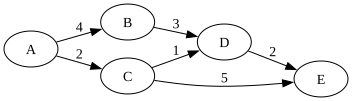

In [52]:
g.visualize('my_graph')

In [53]:
#Test DFS algorithm
print("DFS starting from 'A':", g.dfs('A'))

DFS starting from 'A': [('A', 'B'), ('B', 'D'), ('D', 'E'), ('A', 'C')]


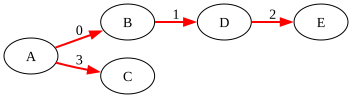

In [54]:
# Visualize the DFS traversal
dfs_dot = g.visualize_traversal(g.dfs('A'), filename="DFS Traversal Ex1", title='DFS Traversal')

In [55]:
dfs_dot.render("dfs_traversal", view=True, format='png', cleanup=True)     # Save the graph to a png file and display it

'dfs_traversal.png'

In [ ]:
#Test BFS algorithm
print("BFS starting from 'A':", g.bfs('A'))

BFS starting from 'A': [('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'E')]


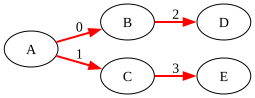

In [ ]:
# Visualize the BFS traversal
bfs_dot = g.visualize_traversal(g.bfs('A'), filename="BFS Traversal Ex1", title='BFS Traversal')

In [58]:
bfs_dot.render("bfs_traversal", view=True, format='png', cleanup=True)     # Save the graph to a png file and display it

'bfs_traversal.png'

In [59]:
#Test Dijkstra's algorithm
distances, previous = g.dijkstra('A')
print("Shortest distances from 'A':", distances)
print("Previous nodes in shortest paths:", previous)

Shortest distances from 'A': {'A': 0, 'B': 4, 'C': 2, 'D': 3, 'E': 5}
Previous nodes in shortest paths: {'A': None, 'B': 'A', 'C': 'A', 'D': 'C', 'E': 'D'}


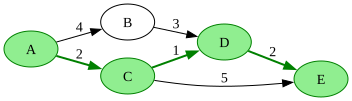

In [60]:
# Visualize shortest path
g.visualize_shortest_path('A', 'E', 'shortest_path')

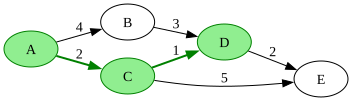

In [61]:
# Visualize shortest path
g.visualize_shortest_path('A', 'D', 'shortest_path')

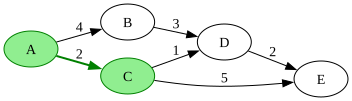

In [62]:
# Visualize shortest path
g.visualize_shortest_path('A', 'C', 'shortest_path')

## Example 2

In [63]:
g2 = Graph()
g2.add_edge('0', '1')
g2.add_edge('0', '5')
g2.add_edge('1', '2')
g2.add_edge('1', '5')
g2.add_edge('1', '3')
g2.add_edge('2', '4')
g2.add_edge('4', '3')
g2.add_edge('5', '6')
g2.add_edge('6', '8')
g2.add_edge('8', '10')
g2.add_edge('10','7')
g2.add_edge('7', '3')
g2.add_edge('7', '9')
g2.add_edge('9', '4')

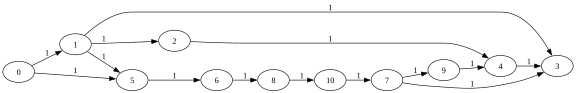

In [64]:
g2.visualize('lecture_graph')

In [65]:
#Test DFS algorithm
print("DFS starting from '0':", g2.dfs('0'))

DFS starting from '0': [('0', '1'), ('1', '2'), ('2', '4'), ('4', '3'), ('1', '5'), ('5', '6'), ('6', '8'), ('8', '10'), ('10', '7'), ('7', '9')]


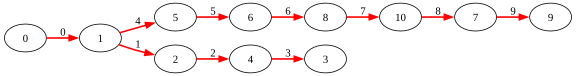

In [68]:
# Visualize the DFS traversal
dfs2_dot = g2.visualize_traversal(g2.dfs('0'), filename="DFS Traversal Ex2", title='DFS Traversal')

In [ ]:
#Test BFS algorithm
print("BFS starting from '0':", g2.bfs('0'))

BFS starting from '0': [('0', '1'), ('0', '5'), ('1', '2'), ('1', '3'), ('5', '6'), ('2', '4'), ('6', '8'), ('8', '10'), ('10', '7'), ('7', '9')]


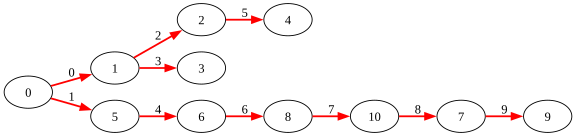

In [ ]:
# Visualize the BFS traversal
bfs2_dot = g2.visualize_traversal(g2.bfs('0'), filename="BFS Traversal Ex2", title='BFS Traversal')

---